# Dynamic Labor Supply: 2-Period Model

## Setup

In [34]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize, NonlinearConstraint
import warnings
warnings.filterwarnings("ignore", message="delta_grad == 0.0. Check if the approximated function is linear.") # turn of annoying warning

from consav.linear_interp import interp_1d

## Solution and Parameters

In [35]:
# per-period utility
def util(C,h,par):
    return (C**(1+par.eta))/(1+par.eta) - par.beta*(h**(1+par.gamma))/(1+par.gamma)

def cons_period2(h2,w2,N2,b,par):
    return (1.0-par.tau)*w2*h2 + N2 - (1+par.r)*b

def value_of_choice1(C1,h1,w1,N1,V2,par): #how much should I consume and work in the first period, given the wage, non-labor income, and value function in the second period?
    
    # current period utility
    u1 = util(C1,h1,par)
    
    # implied borrowing
    b = -((1.0-par.tau)*w1*h1 + N1 - C1)
    
    # next-period value of this level of b
    V2_interp = interp_1d(par.b_grid,V2,b)
    
    # discounted value
    return u1 + par.rho*V2_interp

# solution
def solve(w1,w2,N1,N2,par):
    
    # last period
    V2 = np.nan + np.ones(par.b_grid.size)
    h2_vec = np.nan + np.ones(par.b_grid.size)
    for ib,b in enumerate(par.b_grid):
        obj2 = lambda h: -util( cons_period2(h,w2,N2,b,par) , h,par)
        
        # Set bound based on last-period consumption constraint. If consumption is negative, the solution is not valid.
        h_min = np.fmax(0.0, (b*(1+par.r)-N2)/(w2*(1-par.tau)) ) + 1.0e-5 #We cannot die in debt. We add a small number to avoid hitting the bound exactly, which can cause issues for the optimization algorithm.
        bounds = ((h_min,200.0),) 
        h2_init = np.array([h_min+0.1])
        res = minimize(obj2,h2_init,bounds=bounds)
        
        # store solution
        h2_vec[ib] = res.x[0]
        V2[ib] = -res.fun
        
        
    # first period
    obj1 = lambda x: -value_of_choice1(x[0],x[1],w1,N1,V2,par)
    init = np.array([1.0,2.0])
    bounds = ((0.0001,2000.0),(0.0,2000.0))

    res = minimize(obj1,init,bounds=bounds)
    C1 = res.x[0]
    h1 = res.x[1]
    V1 = -res.fun
    
    return C1,h1,h2_vec

In [36]:
# parameters 
class par: pass
par.beta = 0.1
par.eta = -2.0
par.gamma = 2.5
par.tau = 0.1
par.r = 0.02
par.rho = 1/(1+par.r)

# grid of wealth
par.b_grid = np.linspace(-5.0,15.0,200)

## Solve model

In [37]:
# find optimal labor supply for a given level of wages and non-labor income
w1 = 1.0
w2 = 1.0
N1 = 0.0 # non-labor income. Important for strength of income effect
N2 = 0.0 # non-labor income. Important for strength of income effect
C1,h1,h2_vec = solve(w1,w2,N1,N2,par)

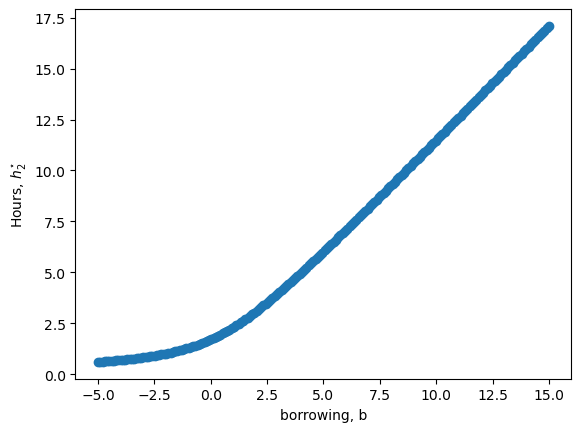

In [38]:
fig, ax = plt.subplots()
ax.scatter(par.b_grid,h2_vec)
ax.set(xlabel='borrowing, b',ylabel='Hours, $h^{\star}_2$');

**Question 1:** Does the last-period optimal hours worked as a function of borrowing have an intuitive slope?

**Check consumption is constant**

In [39]:
# consumption should be rather constant across periods for this parametrization
b = -((1.0-par.tau)*w1*h1 + N1 - C1)
h2 = interp_1d(par.b_grid,h2_vec,b)
C2 = cons_period2(h2,w2,N2,b,par)
print(f'C1={C1:2.3f}, C2={C2:2.3f}')

C1=1.551, C2=1.523


## In-class exercise
1. Look at the code and talk about it with the person next to you for 5 minutes
2. Write at least one question

# Elasticities

**Marshall**

In [40]:
# Marshall elasticity
# theoretical (when rho=1/(1+r) and N1=N2=0)
ela_M = (1+par.eta) / (par.gamma - par.eta)

# simulate permanent increase
C1_,h1_1pct,h2_ = solve(w1*1.01,w2*1.01,N1,N2,par)
ela_M1_sim = (h1_1pct-h1)/h1*100

print(f'Marshall: {ela_M:2.3f}, Simulated: {ela_M1_sim:2.3f}')

Marshall: -0.222, Simulated: -0.215


**Frisch**

In [41]:
# Frisch elasticity
ela_F = 1/par.gamma

# simulate transitory increase in first period
C1_,h1_F,h2_ = solve(w1*1.01,w2,N1,N2,par)
ela_F1_sim = (h1_F-h1)/h1*100

print(f'Frisch: {ela_F:2.3f}, Simulated: {ela_F1_sim:2.3f}')

Frisch: 0.400, Simulated: 0.405


## In-Class Exercise
Include a 10 pct. risk of dying in period two with an associated value of zero. Compare the Frisch elasticity with the original one. Interpret the difference.

$$V_1=\max_{C_1,h_1} U(C_1, h_1)+\rho[P·V_2(b)+(1-P)·0]$$

- 0 is the value associated with death.

## solution

In [42]:
# solution
def value_of_choice1_death(C1,h1,w1,N1,V2,par):
    
    # current period utility
    u1 = util(C1,h1,par)
    
    # implied borrowing
    b = -((1.0-par.tau)*w1*h1 + N1 - C1)
    
    # next-period value of this level of b and alive
    V2_alive = interp_1d(par.b_grid,V2,b)
    
    # value if dead
    V2_death = 0.0
    
    # expected value
    EV2 = par.prob_death*V2_death + (1-par.prob_death)*V2_alive
    
    # discounted value
    return u1 + par.rho*EV2

def solve_death(w1,w2,N1,N2,par):
    
    # last period
    V2 = np.nan + np.ones(par.b_grid.size)
    h2_vec = np.nan + np.ones(par.b_grid.size)
    for ib,b in enumerate(par.b_grid):
        obj2 = lambda h: -util( cons_period2(h,w2,N2,b,par) , h,par)
        
        # Set bound based on last-period consumption constraint
        h_min = np.fmax(0.0, (b*(1+par.r)-N2)/(w2*(1-par.tau)) ) + 1.0e-5
        bounds = ((h_min,200.0),)
        h2_init = np.array([h_min+0.1])
        res = minimize(obj2,h2_init,bounds=bounds,tol=1.0e-8)
        
        # store solution
        h2_vec[ib] = res.x[0]
        V2[ib] = -res.fun
        
        
    # first period
    obj1 = lambda x: -value_of_choice1_death(x[0],x[1],w1,N1,V2,par)
    init = np.array([1.0,2.0])
    bounds = ((0.0001,2000.0),(0.0,2000.0))

    res = minimize(obj1,init,bounds=bounds,tol=1.0e-8)
    C1 = res.x[0]
    h1 = res.x[1]
    V1 = -res.fun

    return C1,h1,h2_vec

In [43]:
h2_vec #Levels of optimal labor supply in the second period for different levels of borrowing.


array([ 0.60324418,  0.61150115,  0.61999723,  0.62874253,  0.6377477 ,
        0.64702396,  0.6565645 ,  0.66642097,  0.67658586,  0.68707291,
        0.69789671,  0.70907254,  0.72061669,  0.73254621,  0.74487917,
        0.75763472,  0.77083633,  0.78449745,  0.79864538,  0.81330383,
        0.82849781,  0.84425363,  0.86056688,  0.87754625,  0.89519976,
        0.91348442,  0.93249194,  0.9522552 ,  0.97278747,  0.99418769,
        1.01644933,  1.039621  ,  1.06375014,  1.08889208,  1.11507258,
        1.14235235,  1.1708095 ,  1.20046282,  1.23137827,  1.26361029,
        1.2972134 ,  1.3322428 ,  1.36874956,  1.40681412,  1.44643882,
        1.48771464,  1.53068275,  1.57538575,  1.62187066,  1.67016715,
        1.72033215,  1.77237084,  1.82631534,  1.88218339,  1.93998595,
        1.9997271 ,  2.06140386,  2.12500679,  2.19051884,  2.25792255,
        2.32718747,  2.39827997,  2.47116142,  2.54578818,  2.62211326,
        2.70008627,  2.77965439,  2.86076005,  2.94334937,  3.02

In [44]:
print(h1) #Optimal labor supply in the first period when there is a risk of death. We expect this to be lower than in the case without risk of death, as the value of future consumption is lower when there is a risk of death.

1.6950993230924274


In [57]:
b_actual = -((1.0-par.tau)*w1*h1 + N1 - C1)
h2_actual =interp_1d(par.b_grid,h2_vec,b_actual) #Optimal labor supply in the second period given the actual level of borrowing in the first period.
C2_actual = cons_period2(h2_actual,w2,N2,b_actual,par)
print(b_actual)
print(h2_actual) 
print(C2_actual)

0.025125550431687627
1.7203321122590232
1.5226708395927995


In [58]:
# solve
par.prob_death = 0.1
C1_death,h1_death,h2_vec_death = solve_death(w1,w2,N1,N2,par)

In [59]:
# Frisch elasticity
# simulate transitory increase in first period
_,h1_death_F,_ = solve_death(w1*1.01,w2,N1,N2,par)
ela_F1_death = (h1_death_F-h1_death)/h1_death*100

print(f'Old Frisch: {ela_F:2.3f}, New, with death: {ela_F1_death:2.3f}')

Old Frisch: 0.400, New, with death: 0.398
